In [1]:
import os

import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold

import torch
import tensorkrowch as tk

from utils import *

## Train LR model

In [2]:
cwd = os.path.join(os.getcwd(), '..')

model_name = 'lr'
n_classes = 2

featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

In [3]:
# Load data
# ---------
scaler_type = 'standard'

dataset = ['Chowell_train']
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

dataset = ['Chowell_test']
data_test, scalers_test = load_data(cwd,
                                    featuresNA,
                                    phenoNA,
                                    dataset,
                                    scaler_type)

In [4]:
# Train vanilla model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

loris_van = train_lr_model('vanilla', x_train, y_train, x_test, y_test)

*TRAINING MODEL*

Accuracy: Train: 0.69, Test: 0.72
Balanced accuracy: Train: 0.68, Test: 0.69

*Correct predicitons*
Train:
    Class 0: 486 / 682 (0.7126)
    Class 1: 182 / 282 (0.6454)
Test:
    Class 0: 288 / 388 (0.7423)
    Class 1: 82 / 127 (0.6457)



In [5]:
# Train average model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

loris_avg = train_lr_model('average', x_train, y_train, x_test, y_test)

*TRAINING MODEL*

Accuracy: Train: 0.69, Test: 0.73
Balanced accuracy: Train: 0.68, Test: 0.69

*Correct predicitons*
Train:
    Class 0: 489 / 682 (0.7170)
    Class 1: 180 / 282 (0.6383)
Test:
    Class 0: 294 / 388 (0.7577)
    Class 1: 80 / 127 (0.6299)



## Tensorize

In [6]:
dataset = datasets
data_sketch, scalers_sketch = load_sketch_data(cwd,
                                               featuresNA,
                                               phenoNA,
                                               dataset,
                                               scaler_type,
                                               n_samples=10)

x_sketch = data_sketch[featuresNA].values
y_sketch = data_sketch[phenoNA].values

print(x_sketch.shape)

(297, 21)


In [7]:
# Tensorize model
# ---------------
xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

xt_test = torch.from_numpy(x_test).float()
yt_test = torch.from_numpy(y_test)

xt_sketch = torch.from_numpy(x_sketch).float()
yt_sketch = torch.from_numpy(y_sketch)

sketch_size    = 100
phys_dim       = 2
domain         = None
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False


def fn_model(data, n_bins=6):
    # Get probabilities (numpy)
    y_proba = loris_van.predict_proba(data)
    y_proba = torch.from_numpy(y_proba).float()
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out#.sqrt()

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()


mps = tensorize(fn_model=fn_model,
                embedding=embedding,
                x_train=xt_train,
                y_train=yt_train,
                x_test=xt_test,
                y_test=yt_test,
                x_sketch=xt_sketch,
                y_sketch=yt_sketch,
                sketch_size=sketch_size,
                phys_dim=phys_dim,
                domain=domain,
                bond_dim=bond_dim,
                cum_percentage=cum_percentage,
                batch_size=batch_size,
                device=device,
                dtype=dtype,
                verbose=verbose)

*TENSORIZING MODEL*

Info: {'total_time': 1.016333818435669, 'val_eps': tensor(0.1368)}

MSE: Sketch: 1.29e-02, Train: 0.013, Test: 1.29e-02
tensor([[ 0.3674,  0.6042],
        [ 0.1058,  0.8349],
        [ 0.4430,  0.6031],
        [ 0.7337,  0.3028],
        [ 0.8600,  0.1110],
        [ 0.6446,  0.3902],
        [ 0.1487,  0.7988],
        [ 0.7927,  0.2452],
        [-0.1280,  0.9857],
        [ 0.7096,  0.3098]])
tensor([[0.3333, 0.6667],
        [0.1667, 0.8333],
        [0.3333, 0.6667],
        [0.6667, 0.3333],
        [0.8333, 0.1667],
        [0.6667, 0.3333],
        [0.1667, 0.8333],
        [0.8333, 0.1667],
        [0.0000, 1.0000],
        [0.6667, 0.3333]])
tensor([1, 0, 0, 1, 0, 1, 1, 1, 1, 1])

*Sketch accuracies*
Accuracy: TT: 0.65, LR: 0.66
Balanced accuracy: TT: 0.65, LR: 0.65

*Train/test TT accuracies*
Accuracy: Train: 0.68, Test: 0.71
Balanced accuracy: Train: 0.67, Test: 0.68

*Correct predicitons*
Train:
    Class 0: 477 / 682 (0.6994)
    Class 1: 182 / 282 

In [8]:
# Renormalize model
# -----------------

# We renormalize the tensor network so that it represents a normalized
# distribution of all the features, instead of only giving normalized
# conditional distributions for the output feature ("Response")

# Contiuous variables have to be integrated. "discr_steps" indicates the number
# of dicretization steps used to discretize the continuous variable and perform
# numerical integration
discr_steps = int(1e5)

print('* RENORMALIZING TN MODEL:')
mps = renormalize(mps=mps,
                  phys_dim=phys_dim,
                  discr_steps=discr_steps,
                  n_classes=n_classes,
                  num_features=numeric_featuresNA,
                  x_train=xt_train,
                  y_train=yt_train,
                  x_test=xt_test,
                  y_test=yt_test)

* RENORMALIZING TN MODEL:
Norm: 125375.8672
Model accuracy: Train: 0.68, Test: 0.71
Model balanced accuracy: Train: 0.67, Test: 0.68
Correct predicitons
Train:
    Class 0: 477 / 682 (0.6994)
    Class 1: 182 / 282 (0.6454)
Test:
    Class 0: 284 / 388 (0.7320)
    Class 1: 80 / 127 (0.6299)



In [9]:
def lr_van_model(data):
    result = torch.from_numpy(loris_van.predict_proba(data)).float()
    return result

def lr_avg_model(data):
    result = torch.from_numpy(loris_avg.predict_proba(data)).float()
    return result

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()

def tt_model(data):
    result = mps(embedding(data))#.pow(2)
    result = result / result.sum(dim=1, keepdim=True)
    return result

In [10]:
lr_van_model(xt_test)

tensor([[0.2541, 0.7459],
        [0.4482, 0.5518],
        [0.5097, 0.4903],
        ...,
        [0.5680, 0.4320],
        [0.7511, 0.2489],
        [0.5113, 0.4887]])

In [11]:
lr_avg_model(xt_test)

tensor([[0.2660, 0.7340],
        [0.4541, 0.5459],
        [0.5107, 0.4893],
        ...,
        [0.5705, 0.4295],
        [0.7417, 0.2583],
        [0.5104, 0.4896]])

In [12]:
tt_model(xt_test)

tensor([[0.2090, 0.7910],
        [0.4616, 0.5384],
        [0.5438, 0.4562],
        ...,
        [0.6094, 0.3906],
        [0.8693, 0.1307],
        [0.4357, 0.5643]], grad_fn=<DivBackward0>)

In [13]:
evaluate_by_cancer(lr_van_model, xt_train, yt_train, scalers_train)

CancerType1: Train accuracy: 0.75, Train balanced accuracy: 0.62
Correct predicitons
Train:
    Class 0: 44 / 53 (0.8302)
    Class 1: 5 / 12 (0.4167)

CancerType2: Train accuracy: 0.92, Train balanced accuracy: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

CancerType3: Train accuracy: 0.86, Train balanced accuracy: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

CancerType4: Train accuracy: 0.78, Train balanced accuracy: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

CancerType5: Train accuracy: 0.62, Train balanced accuracy: 0.66
Correct predicitons
Train:
    Class 0: 6 / 14 (0.4286)
    Class 1: 9 / 10 (0.9000)

CancerType6: Train accuracy: 0.84, Train balanced accuracy: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

CancerType7: Train accuracy: 0.79, Train balanced accuracy: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [14]:
evaluate_by_cancer(tt_model, xt_train, yt_train, scalers_train)

CancerType1: Train accuracy: 0.74, Train balanced accuracy: 0.61
Correct predicitons
Train:
    Class 0: 43 / 53 (0.8113)
    Class 1: 5 / 12 (0.4167)

CancerType2: Train accuracy: 0.92, Train balanced accuracy: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

CancerType3: Train accuracy: 0.86, Train balanced accuracy: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

CancerType4: Train accuracy: 0.78, Train balanced accuracy: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

CancerType5: Train accuracy: 0.54, Train balanced accuracy: 0.59
Correct predicitons
Train:
    Class 0: 4 / 14 (0.2857)
    Class 1: 9 / 10 (0.9000)

CancerType6: Train accuracy: 0.84, Train balanced accuracy: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

CancerType7: Train accuracy: 0.79, Train balanced accuracy: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## Study distributions

### Examples

In [15]:
# Get conditional/marginal distribution
# -------------------------------------

# We need to specify the condition and marginal variables. The rest will be
# marginalized out. The "Response" feature can be included as condition or
# marginal

# Select features on which we condition
cond_features = ['TMB', 'Albumin']

# Create tensor with values (already scaled to [0, 1])
# for conditioned features
cond_data = [0.2, 0.9]  # Just an example

# Select features which we marginalize
marg_features = ['Systemic_therapy_history', 'Response']

# In this example, we will get the distribution 
# P('Systemic_therapy_history', 'Response' | 'TMB', 'Albumin'),
# marginalizing out the rest of the features

# The distribution will be given as a tensor with shape:
# (dim_marg_1, ..., dim_marg_n), with "dim_marg_{i}" being the dimensions of
# each marginal feature. These marginal features could be returned in a
# different order as the one specified in "marg_features". The order will
# be returned in the list "marg_feat_order"

# For continuous features, the dimension of the marginal features will be the
# specified "discr_steps"

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print(marg_feat_order[1], distr.sum(dim=0))
print(marg_feat_order[0], distr.sum(dim=1))
print()

['Systemic_therapy_history', 'Response'] torch.Size([2, 2])
tensor([[0.2751, 0.1980],
        [0.4302, 0.0968]])
tensor(1.)
Response tensor([0.7053, 0.2947])
Systemic_therapy_history tensor([0.4731, 0.5269])



In [16]:
# Example 2
cond_features = ['Response']
cond_data = [1.]

marg_features = ['TMB']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['TMB'] torch.Size([10])
tensor([0.0060, 0.0154, 0.0291, 0.0471, 0.0694, 0.0961, 0.1270, 0.1623, 0.2019,
        0.2457])
tensor(1.0000)



In [17]:
# Example 3
cond_features = ['Systemic_therapy_history']
cond_data = [0.]

marg_features = ['Response']

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['Response'] torch.Size([2])
tensor([0.5533, 0.4467])
tensor(1.)



In [18]:
# Example 4
cond_features = []
cond_data = []

marg_features = ['Response', 'Albumin']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr / distr.sum(dim=1, keepdim=True))
print()

['Albumin', 'Response'] torch.Size([10, 2])
tensor([[0.9721, 0.0279],
        [0.9370, 0.0630],
        [0.8847, 0.1153],
        [0.8151, 0.1849],
        [0.7298, 0.2702],
        [0.6330, 0.3670],
        [0.5306, 0.4694],
        [0.4293, 0.5707],
        [0.3349, 0.6651],
        [0.2517, 0.7483]])



### Feature Importance

In [19]:
# TMB: We know TMB above 27 indicates better response

low = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=5,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=27,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('TMB Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

TMB Example:
TT Score: 0.0418, 0.3593, 0.8221



In [20]:
# Age: We know Age has a small impact on response

low = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=30,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=80,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('Age Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

Age Example:
TT Score: 0.2670, 0.3176, 0.3987



In [21]:
# PSTH: We know that history of treatment lowers effectiveness of treatment

low = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=0,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=1,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('PSTH Example:')
print(f'TT Score: {low:.4f}, {high:.4f}')
print()

PSTH Example:
TT Score: 0.7942, 0.2673



### Individual Patient Predictions

In [22]:
# Patient 1 -> Cancer: Melanoma, PSTH: No, Age: 64, Albumin: 4.8
#              NLR: 4.7, PD-L1: –, TMB: 21

patient = [21, 4.8, 4.7, 64, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.7942
LORIS (average) score: 0.7888
TT Score: 0.8284



In [23]:
# Patient 2 -> Cancer: NSCLC, PSTH: Yes, Age: 50, Albumin: 3.5,
#              NLR: 6.3, PD-L1: –, TMB: 8

patient = [8, 3.5, 6.3, 50, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.3138
LORIS (average) score: 0.3209
TT Score: 0.2591



In [24]:
# Patient 3 -> Cancer: Breast, PSTH: No,, Age: 42, Albumin: 4.6,
#              NLR: 2.3, PD-L1: –, TMB: 5

patient = [5, 4.6, 2.3, 42, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()


Patient 1:
LORIS (vanilla) score: 0.5794
LORIS (average) score: 0.5913
TT Score: 0.5796



### Feature Sensitivity

Confguration for figures

In [25]:
plt.rc('font', family='serif', serif='Computer Modern', size=16)
plt.rc('text', usetex=True)

# Set global font sizes
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0
plt.rcParams['axes.titlesize'] = 15   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 12

# Replace label just for plotting
plot_labels = {
    'TMB': 'TMB',
    'Albumin': 'Albumin',
    'NLR': 'NLR',
    'Age': 'Age',
    'Systemic_therapy_history': 'PSTH',
    'CancerType1': 'Bladder',  # cancer
    'CancerType2': 'Breast',  # cancer
    'CancerType3': 'Colorectal',  # cancer
    'CancerType4': 'Endometrial',  # cancer
    'CancerType5': 'Esophageal',  # cancer
    'CancerType6': 'Gastric',  # cancer
    'CancerType7': 'Head and Neck',  # cancer
    'CancerType8': 'Hepatobiliary',  # cancer
    'CancerType9': 'Melanoma',
    'CancerType10': 'Mesothelioma',
    'CancerType11': 'Non-small cell lung',  # cancer
    'CancerType12': 'Ovarian',  # cancer
    'CancerType13': 'Pancreatic',  # cancer
    'CancerType14': 'Renal',  # cancer
    'CancerType15': 'Sarcoma',
    'CancerType16': 'Small cell lung'  # cancer
}

figures_dir = os.path.join(cwd, 'interpretability', 'figures')

Conditioning on mean values

In [26]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_cond(feat, lr_avg_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_cond(feat, tt_model, xt_train,
                                              featuresNA, scalers_train))

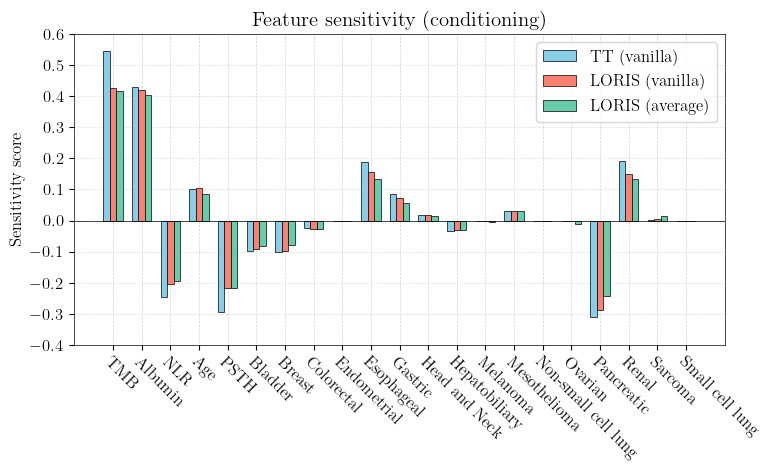

In [27]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (conditioning)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_cond.pdf'),
            bbox_inches='tight')
plt.show()

Marginalizing variables

In [28]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_cond(feat, lr_avg_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_marg(feature=feat,
                                              mps=mps,
                                              in_features=featuresNA,
                                              out_feature=phenoNA,
                                              num_features=numeric_featuresNA,
                                              n_classes=n_classes,
                                              phys_dim=phys_dim,
                                              x_train=xt_train,
                                              discr_steps=int(1e5),
                                              scalers_dict=scalers_train))

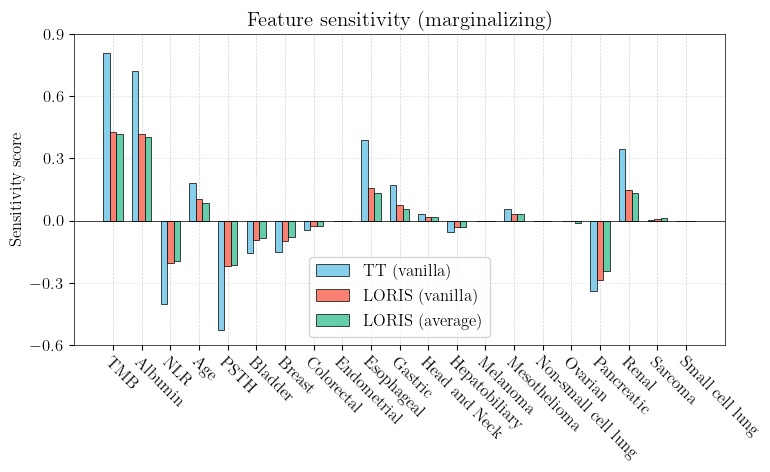

In [29]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (marginalizing)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='lower center')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.3)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_marg.pdf'),
            bbox_inches='tight')
plt.show()

Recovering LR coefficiets from the TT

In [30]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_coeffs(feat, lr_van_model, xt_train,
                                                    featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_coeffs(feat, lr_avg_model, xt_train,
                                                    featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_coeffs(feat, tt_model, xt_train,
                                                featuresNA, scalers_train))

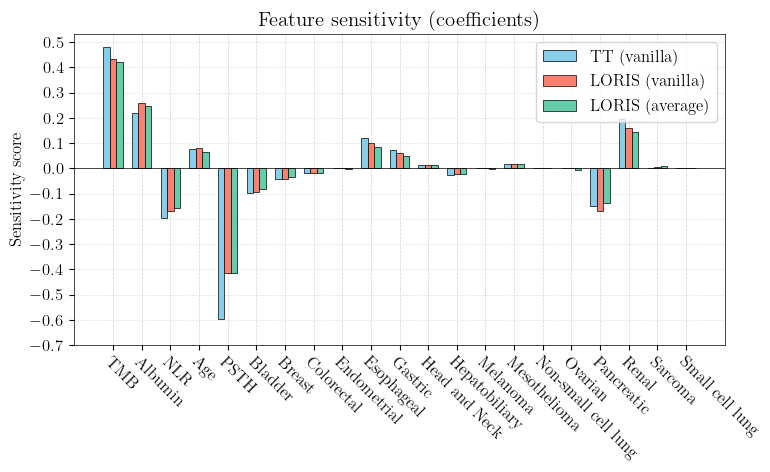

In [31]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (coefficients)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
            bbox_inches='tight')
plt.show()

### Feature sensitivity by CancerType

Conditioning on mean values

In [34]:
aux_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history']

cancer_features = ['CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
                   'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
                   'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
                   'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

mps.reset()
mps.unset_data_nodes()

scores_by_cancer = []
train_baccs = []
for cancer_idx in range(16):
    # print(cancer_idx)
    cancer_scores = []
    
    # print(feat)
    aux_mps, aux_xt_train, aux_yt_train, train_bal_acc = get_cancertype_mps(
        mps, phys_dim, cancer_idx, xt_train, yt_train, scalers_train)
    train_baccs.append(train_bal_acc)
    
    # print(aux_mps.tensors)
    
    @torch.no_grad()
    def aux_tt_model(data):
        result = aux_mps(embedding(data))#.pow(2)
        result = result / result.sum(dim=1, keepdim=True)
        return result
        
    for feat in aux_featuresNA:
        # print(feat)
        cancer_scores.append(feature_sensitivity_cond(feat, aux_tt_model,
                                                      aux_xt_train, aux_featuresNA,
                                                      scalers_train))
    # print(cancer_scores)
    scores_by_cancer.append(cancer_scores)
    # print()
    # print()

Model accuracy: Train: 0.74
Model balanced accuracy: Train: 0.61
Correct predicitons
Train:
    Class 0: 43 / 53 (0.8113)
    Class 1: 5 / 12 (0.4167)

Model accuracy: Train: 0.92
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

Model accuracy: Train: 0.86
Model balanced accuracy: Train: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

Model accuracy: Train: 0.78
Model balanced accuracy: Train: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

Model accuracy: Train: 0.54
Model balanced accuracy: Train: 0.59
Correct predicitons
Train:
    Class 0: 4 / 14 (0.2857)
    Class 1: 9 / 10 (0.9000)

Model accuracy: Train: 0.84
Model balanced accuracy: Train: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

Model accuracy: Train: 0.79
Model balanced accuracy: Train: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Model accuracy: Train: 0.71
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 23 / 26 (0.8846)
    Class 1: 1 / 8 (0.1250)



In [ ]:
scores_by_cancer

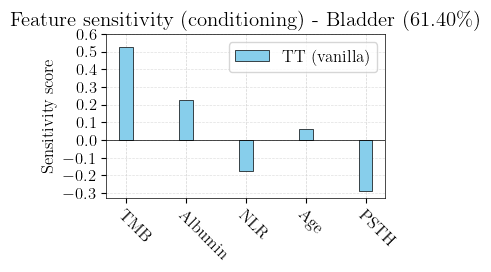

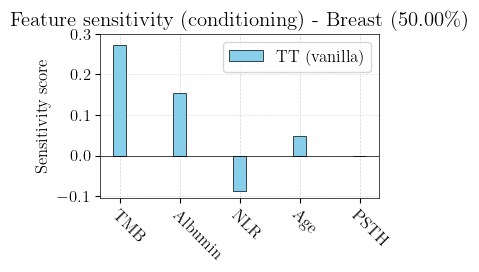

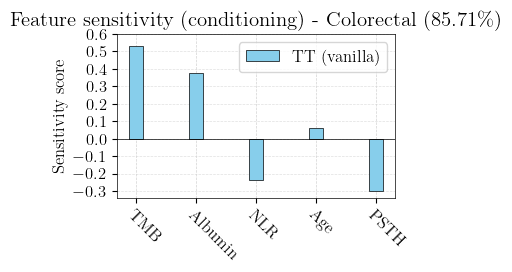

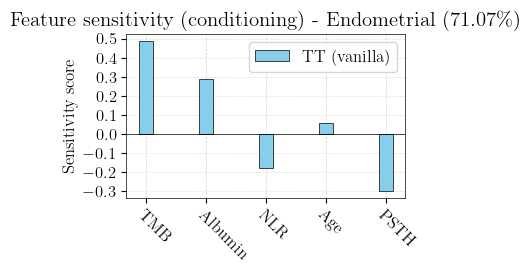

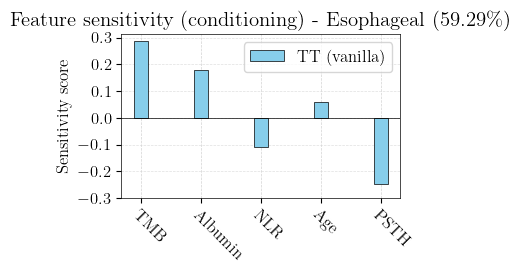

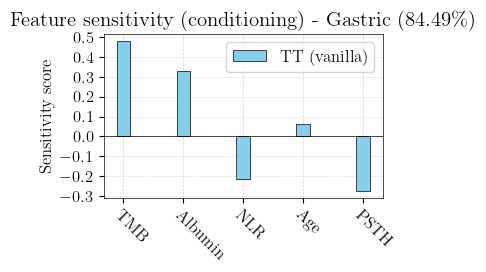

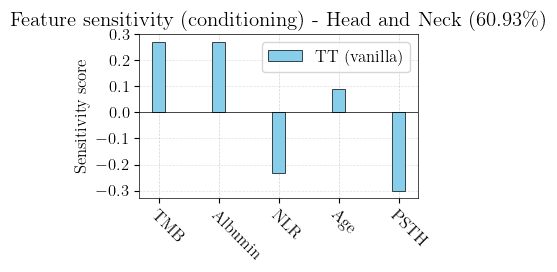

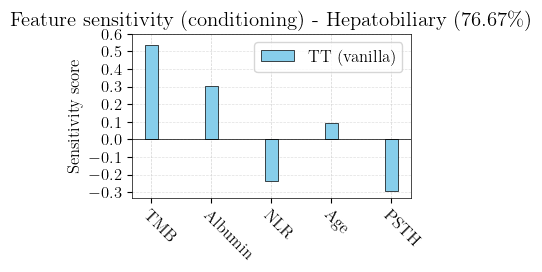

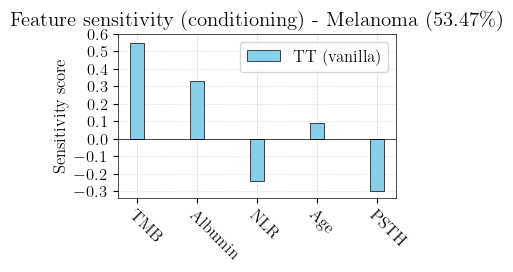

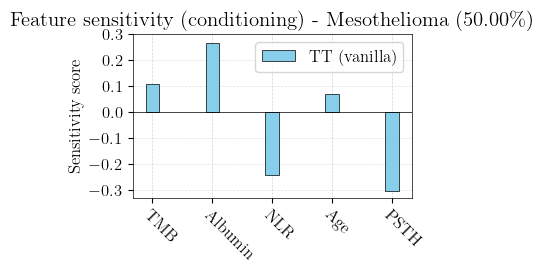

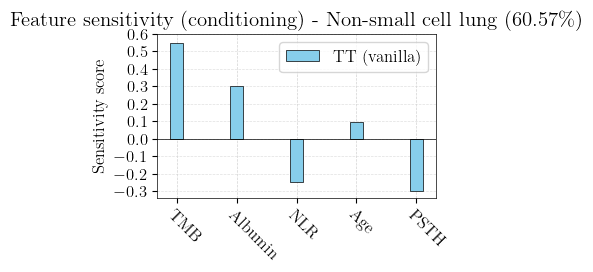

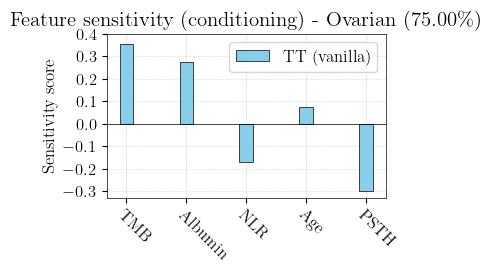

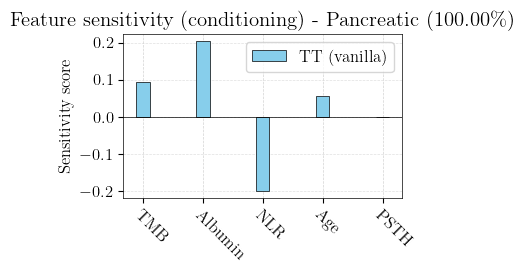

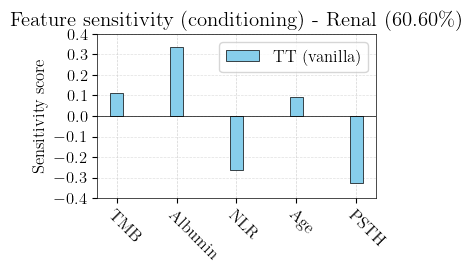

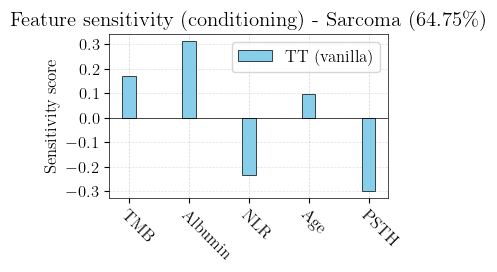

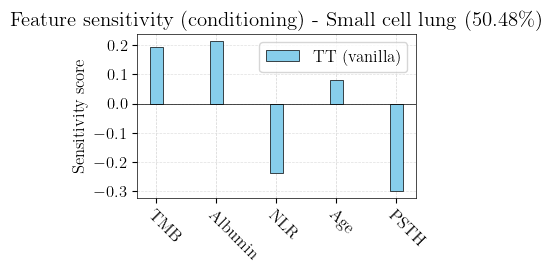

In [38]:
for cancer_idx in range(16):
    # Bar plot setup
    x = torch.arange(len(aux_featuresNA)) * 2  # label locations
    width = 0.45  # width of the bars

    fig, ax = plt.subplots(figsize=(4, 3))
    bars = ax.bar(x, scores_by_cancer[cancer_idx], width, 
                  label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)

    # Axes settings
    # ax.set_xlabel('Feature')
    ax.set_ylabel('Sensitivity score')
    ax.set_title(f'Feature sensitivity (conditioning) - '
                 f'{list(plot_labels.values())[cancer_idx + 5]} '
                 f'({train_baccs[cancer_idx] * 100:.2f}\%)')
    ax.set_xticks(x)
    ax.set_xticklabels([plot_labels[feat] for feat in aux_featuresNA],
                    rotation=-45, ha='left', rotation_mode='anchor')
    ax.legend(loc='upper right')

    # Horizontal line at y=0
    ax.axhline(0, color='black', linewidth=0.5)

    # Vertical lines at each x-tick
    for xpos in x:
        ax.axvline(x=xpos, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

    # Y-ticks every 0.1
    ymin, ymax = ax.get_ylim()
    yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
    ax.set_yticks(yticks)

    # Horizontal grey lines at each y-tick
    for y in yticks:
        ax.axhline(y=y, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

    plt.tight_layout()
    # plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
                # bbox_inches='tight')
    plt.show()

Marginalizing variables

In [39]:
aux_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history']

cancer_features = ['CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
                   'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
                   'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
                   'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

mps.reset()
mps.unset_data_nodes()

scores_by_cancer = []
train_baccs = []
for cancer_idx in range(16):
    # print(cancer_idx)
    cancer_scores = []
    
    # print(feat)
    aux_mps, aux_xt_train, aux_yt_train, train_bal_acc = get_cancertype_mps(
        mps, phys_dim, cancer_idx, xt_train, yt_train, scalers_train)
    train_baccs.append(train_bal_acc)
    
    # print(aux_mps.tensors)
    
    @torch.no_grad()
    def aux_tt_model(data):
        result = aux_mps(embedding(data))#.pow(2)
        result = result / result.sum(dim=1, keepdim=True)
        return result
        
    for feat in aux_featuresNA:
        # print(feat)
        cancer_scores.append(feature_sensitivity_marg(feature=feat,
                                                      mps=aux_mps,
                                                      in_features=aux_featuresNA,
                                                      out_feature=phenoNA,
                                                      num_features=numeric_featuresNA,
                                                      n_classes=n_classes,
                                                      phys_dim=phys_dim,
                                                      x_train=aux_xt_train,
                                                      discr_steps=int(1e5),
                                                      scalers_dict=scalers_train))
    # print(cancer_scores)
    scores_by_cancer.append(cancer_scores)
    # print()
    # print()

Model accuracy: Train: 0.74
Model balanced accuracy: Train: 0.61
Correct predicitons
Train:
    Class 0: 43 / 53 (0.8113)
    Class 1: 5 / 12 (0.4167)

Model accuracy: Train: 0.92
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

Model accuracy: Train: 0.86
Model balanced accuracy: Train: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

Model accuracy: Train: 0.78
Model balanced accuracy: Train: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

Model accuracy: Train: 0.54
Model balanced accuracy: Train: 0.59
Correct predicitons
Train:
    Class 0: 4 / 14 (0.2857)
    Class 1: 9 / 10 (0.9000)

Model accuracy: Train: 0.84
Model balanced accuracy: Train: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

Model accuracy: Train: 0.79
Model balanced accuracy: Train: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Model accuracy: Train: 0.71
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 23 / 26 (0.8846)
    Class 1: 1 / 8 (0.1250)



In [40]:
scores_by_cancer

[[0.8199268765747547,
  0.44611792266368866,
  -0.286483496427536,
  0.11326467990875244,
  -0.48451370000839233],
 [0.4101981557905674,
  0.2345018908381462,
  -0.12644453346729279,
  0.06808741390705109,
  0.0],
 [0.7127011901466176,
  0.573604354634881,
  -0.3386973738670349,
  0.09257788956165314,
  -0.5419703125953674],
 [0.740441819652915,
  0.5141047909855843,
  -0.30157555639743805,
  0.10187245905399323,
  -0.54054856300354],
 [0.5153304934501648,
  0.3523102104663849,
  -0.20681792497634888,
  0.11394745111465454,
  -0.33225613832473755],
 [0.7583798784762621,
  0.6168750077486038,
  -0.38642384111881256,
  0.12696236371994019,
  -0.5212882459163666],
 [0.3633681498467922,
  0.3516321927309036,
  -0.2896408699452877,
  0.11924199014902115,
  -0.5447509065270424],
 [0.7748091649264097,
  0.5290822498500347,
  -0.35959526896476746,
  0.15345259010791779,
  -0.5289009213447571],
 [0.8570128101855516,
  0.6417722851037979,
  -0.41655541956424713,
  0.17168501019477844,
  -0.51048

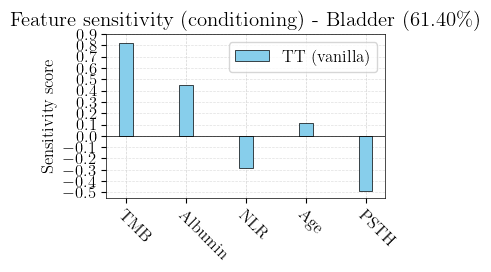

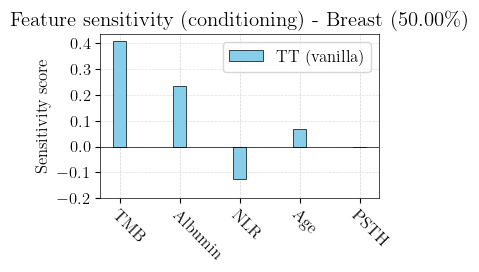

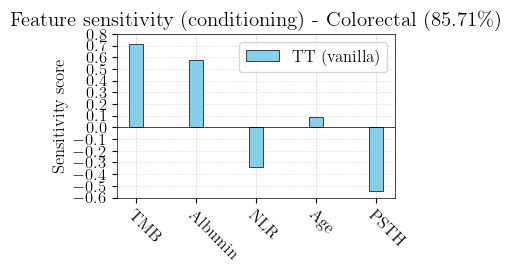

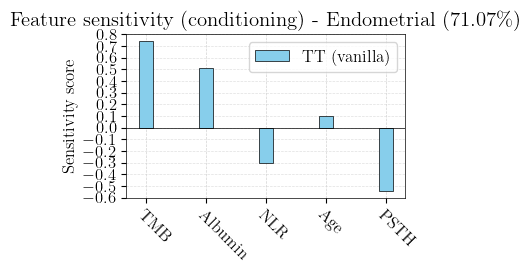

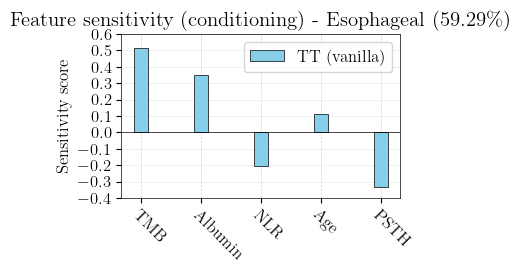

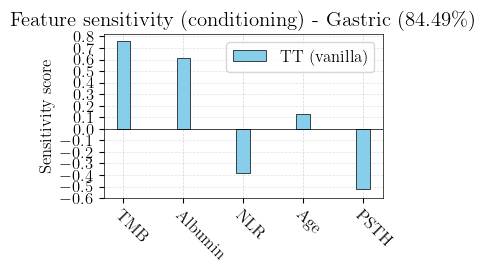

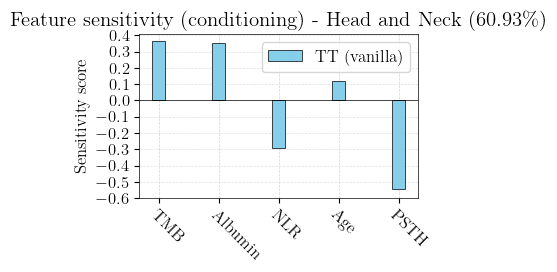

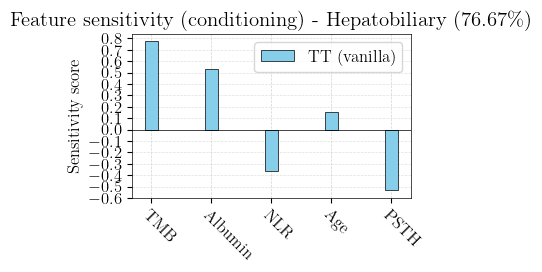

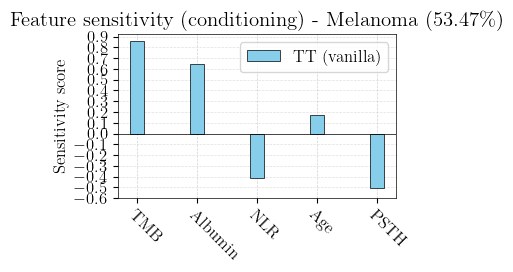

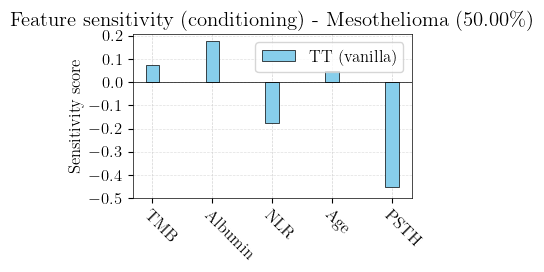

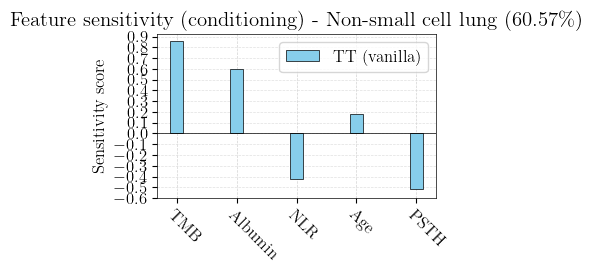

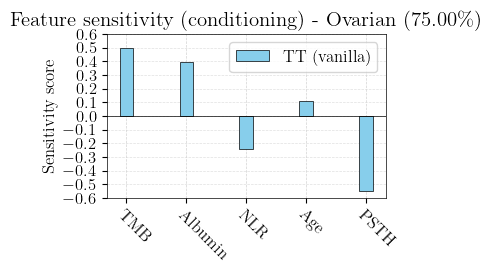

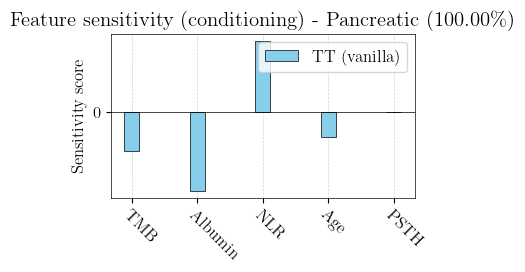

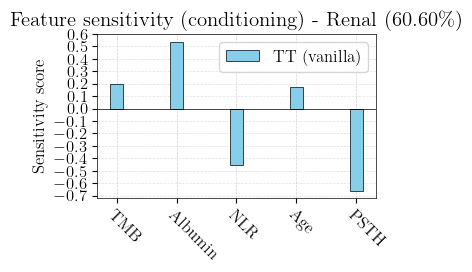

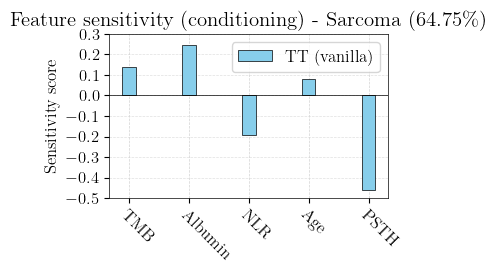

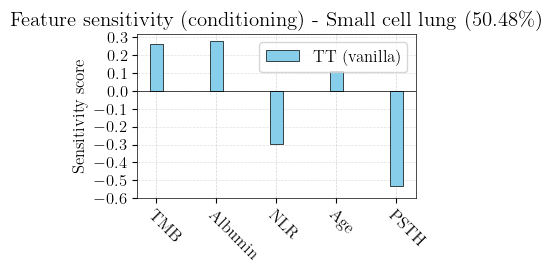

In [41]:
for cancer_idx in range(16):
    # Bar plot setup
    x = torch.arange(len(aux_featuresNA)) * 2  # label locations
    width = 0.45  # width of the bars

    fig, ax = plt.subplots(figsize=(4, 3))
    bars = ax.bar(x, scores_by_cancer[cancer_idx], width, 
                  label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)

    # Axes settings
    # ax.set_xlabel('Feature')
    ax.set_ylabel('Sensitivity score')
    ax.set_title(f'Feature sensitivity (conditioning) - '
                 f'{list(plot_labels.values())[cancer_idx + 5]} '
                 f'({train_baccs[cancer_idx] * 100:.2f}\%)')
    ax.set_xticks(x)
    ax.set_xticklabels([plot_labels[feat] for feat in aux_featuresNA],
                    rotation=-45, ha='left', rotation_mode='anchor')
    ax.legend(loc='upper right')

    # Horizontal line at y=0
    ax.axhline(0, color='black', linewidth=0.5)

    # Vertical lines at each x-tick
    for xpos in x:
        ax.axvline(x=xpos, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

    # Y-ticks every 0.1
    ymin, ymax = ax.get_ylim()
    yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
    ax.set_yticks(yticks)

    # Horizontal grey lines at each y-tick
    for y in yticks:
        ax.axhline(y=y, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

    plt.tight_layout()
    # plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
                # bbox_inches='tight')
    plt.show()

## Monotonic plots

In [42]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'minmax'
scaler_type = 'standard'

dataset = ['Chowell_train'] # 'MSK1', 'MSK2'
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

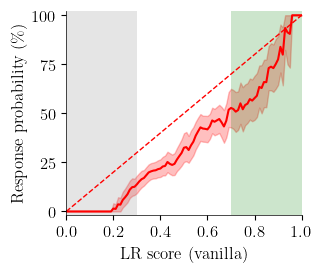

In [43]:
response_curve(lr_van_model, xt_train, yt_train, xlabel='LR score (vanilla)')

plt.savefig(os.path.join(figures_dir, 'monotonic_lr_van.pdf'),
            bbox_inches='tight')
plt.show()

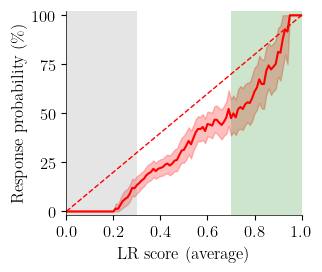

In [44]:
response_curve(lr_avg_model, xt_train, yt_train, xlabel='LR score (average)')

plt.savefig(os.path.join(figures_dir, 'monotonic_lr_avg.pdf'),
            bbox_inches='tight')
plt.show()

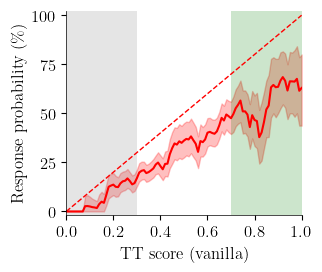

In [45]:
response_curve(tt_model, xt_train, yt_train, xlabel='TT score (vanilla)')

plt.savefig(os.path.join(figures_dir, 'monotonic_tt.pdf'),
            bbox_inches='tight')
plt.show()